<a href="https://colab.research.google.com/github/mirzulqarnain/DEEP_LEARNING_REPS/blob/main/Xavier_weights_init.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('/content/ushape.csv')

In [4]:
df.head()

,3.159499363321345566e-02,9.869877579082642072e-01,0.000000000000000000e+00
0,2.115098,-0.046244,1.0
1,0.882490,-0.075756,0.0
2,-0.055144,-0.037332,1.0
3,0.829545,-0.539321,1.0
4,2.112857,0.662084,1.0


In [6]:
df.columns = ['X', 'Y', 'class']

In [7]:
df.head()

,X,Y,class
0,2.115098,-0.046244,1.0
1,0.882490,-0.075756,0.0
2,-0.055144,-0.037332,1.0
3,0.829545,-0.539321,1.0
4,2.112857,0.662084,1.0


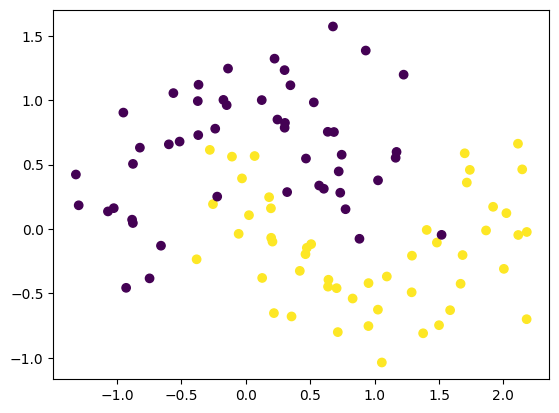

In [8]:
plt.scatter(df['X'], df['Y'], c=df['class'])


In [9]:
X =df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [10]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [11]:
model = Sequential()
model.add(Dense(10, activation='tanh', input_dim=2))
model.add(Dense(10, activation='tanh'))
model.add(Dense(10, activation='tanh'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 261 (1.02 KB)

 Trainable params: 261 (1.02 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.get_weights()

[array([[-0.57001066,  0.21485943, -0.13476843, -0.2535025 ,  0.16726702,
          0.52230805,  0.5964957 , -0.6249875 , -0.50896144, -0.4713024 ],
        [ 0.468347  ,  0.49665254, -0.31366628,  0.56407624,  0.641527  ,
         -0.36473495, -0.1690616 , -0.42719352, -0.12235618, -0.47676158]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.3983727 ,  0.39492977,  0.07012337, -0.00308537, -0.07104534,
          0.54396844, -0.2305404 ,  0.28719085, -0.34398717, -0.34526795],
        [ 0.2831002 , -0.18754143,  0.4737085 , -0.34487385,  0.4874555 ,
         -0.52384716, -0.27997395,  0.20699269, -0.09296846,  0.5429641 ],
        [-0.38557214,  0.28607357,  0.15167367, -0.08101502, -0.26971176,
         -0.43489337,  0.27055246, -0.00634277,  0.38613588,  0.31266254],
        [-0.262402  ,  0.23377323,  0.01056832, -0.40265125,  0.07319117,
         -0.4126468 ,  0.29331028, -0.4677968 , -0.37926114,  0.3111062 ],
        [ 0.52376

In [14]:
initial_weights = model.get_weights()

In [17]:
initial_weights[0]=np.random.randn(2,10)*np.sqrt(1/2)
initial_weights[1]=np.zeros(model.get_weights()[1].shape)
initial_weights[2]=np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[3]=np.zeros(model.get_weights()[3].shape)
initial_weights[4]=np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[5]=np.zeros(model.get_weights()[5].shape)
initial_weights[6]=np.random.randn(10,1)*np.sqrt(1/10) # Corrected shape for output layer weights
initial_weights[7]=np.zeros(model.get_weights()[7].shape)


In [18]:
model.set_weights(initial_weights)

In [19]:
model.get_weights()

[array([[-0.9736857 ,  0.20341949,  0.74222964,  0.8305405 , -1.6054204 ,
          1.0988512 , -0.6611924 , -1.6934737 , -0.11926915,  0.66008615],
        [-0.86047953, -0.3441184 ,  0.7087059 , -0.45372835,  1.5289164 ,
         -0.17594574, -0.5776485 , -0.4160316 ,  0.13888852, -0.10162453]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.17750339, -0.8680266 ,  0.09076177, -0.2653524 ,  0.29531857,
          0.44928765,  0.17194667,  0.41694018,  0.50918347,  0.34849447],
        [ 0.07536367,  0.7181059 , -0.43570375,  0.06114029, -0.00408247,
         -0.08542246,  0.65321654,  0.05486503, -0.4078687 ,  0.18172339],
        [ 0.39664927, -0.02360952,  0.05298843, -0.00608609,  0.23583204,
          0.63529015,  0.507357  , -0.2558655 ,  0.07625032, -0.10726258],
        [-0.01810507, -0.77691287,  0.03778604,  0.18303682, -0.6888426 ,
         -0.07180725,  0.11532515,  0.3741314 , -0.12519026, -0.7707219 ],
        [ 0.21390

In [21]:

model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [22]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - accuracy: 0.5696 - loss: 0.7189 - val_accuracy: 0.7500 - val_loss: 0.6173
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5823 - loss: 0.7077 - val_accuracy: 0.7500 - val_loss: 0.6053
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5823 - loss: 0.6989 - val_accuracy: 0.7500 - val_loss: 0.5937
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5949 - loss: 0.6892 - val_accuracy: 0.7500 - val_loss: 0.5840
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6076 - loss: 0.6814 - val_accuracy: 0.7500 - val_loss: 0.5744
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6203 - loss: 0.6740 - val_accuracy: 0.8000 - val_loss: 0.5653
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6203 - loss: 0.6669 - val_accuracy: 0.8000 - val_loss: 0.5568
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6329 - loss: 0.6600 - val_accuracy: 0.8000 - val_loss

In [23]:
model.get_weights()

[array([[-1.064154  ,  0.20995645,  0.81314844,  0.6153668 , -1.2635969 ,
          0.8750446 , -0.5037119 , -1.594523  , -0.12515776,  0.44795284],
        [-0.7521628 , -0.5419713 ,  0.7001377 , -0.53926027,  1.8276453 ,
         -0.32951045, -0.8358784 , -0.34072676,  0.3975706 , -0.1762276 ]],
       dtype=float32),
 array([-0.16308276, -0.00138672, -0.11448658,  0.1537848 ,  0.2267499 ,
         0.09309253,  0.07213387, -0.1254217 , -0.01219859, -0.1341677 ],
       dtype=float32),
 array([[-0.12821259, -0.7722861 , -0.08100424, -0.34681818,  0.12001257,
          0.33383474,  0.37896854,  0.43994018,  0.3718733 ,  0.3589561 ],
        [ 0.12901817,  0.8834773 , -0.6240151 ,  0.09060447, -0.1539043 ,
         -0.26221862,  0.836947  ,  0.12489169, -0.6236796 ,  0.3300073 ],
        [ 0.33666903, -0.15557134,  0.22276716,  0.07983153,  0.4392547 ,
          0.7712828 ,  0.2794739 , -0.33999753,  0.22441249, -0.11226261],
        [ 0.03589389, -0.63371265,  0.03185572,  0.19471468, 

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


<Axes: >

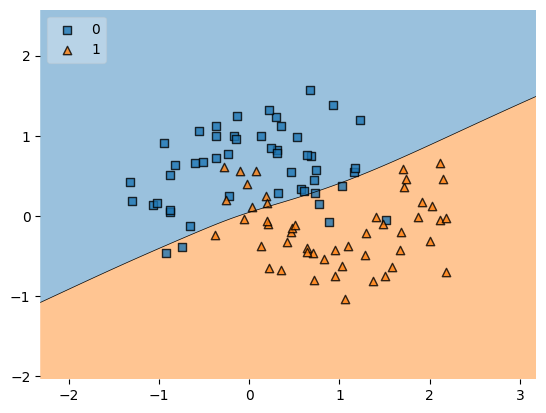

In [25]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype("int"), clf=model,legend=2)
